In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

In [2]:
# Open the FITS file
with fits.open('binary_catalog.fits') as hdul:
    # Read the data into an Astropy Table
    binary_cat = Table(hdul[1].data)

In [3]:
# Extract data
sep_AU = binary_cat['sep_AU']
theta = binary_cat['pairdistance'] * 3600  # Convert degrees to arcsec
G1 = binary_cat['phot_g_mean_mag1']
G2 = binary_cat['phot_g_mean_mag2']
parallax = binary_cat['parallax1']# Under the assumption that the two components have the same
                                  # distance, we use the (usually more precise) parallax of the 
                                  # primary, (the brighter star) for both components when 
                                  # calculating Mg
b = binary_cat['dec1']  # galactic latitude
v_perp = np.sqrt(binary_cat['pmra1']**2 + binary_cat['pmdec1']**2) * 4.74 * (1/parallax)  # plane-of-the-sky velocity in km/s
bp_rp1 = binary_cat['bp_rp1']
bp_rp2 = binary_cat['bp_rp2']

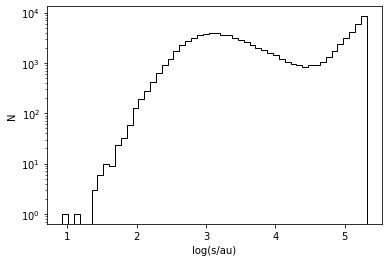

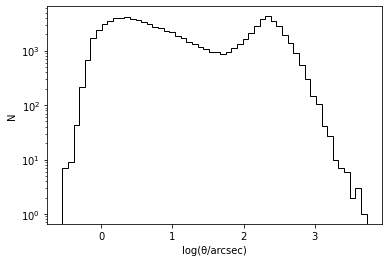

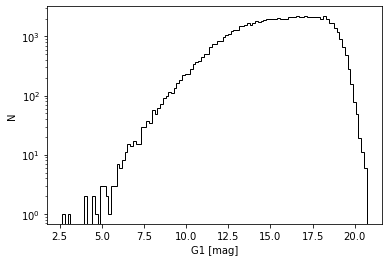

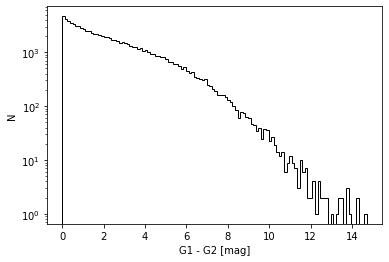

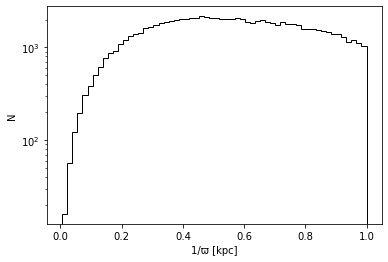

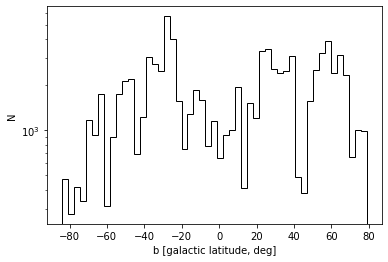

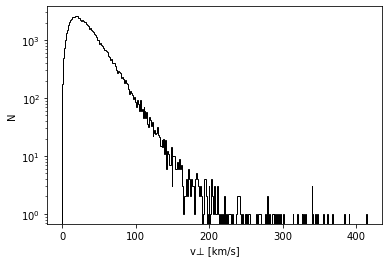

In [4]:
#ploting the histogram, bins type 'fd' is used as for large data it automatically decides the bin number

# log(s/au)
plt.hist(np.log10(sep_AU), bins='fd', histtype='step', label='All', color='black')
plt.xlabel('log(s/au)')
plt.ylabel('N')
plt.yscale('log')
plt.show()

# log(θ/arcsec)
plt.hist(np.log10(theta), bins='fd', histtype='step', label='All', color='black')
plt.xlabel('log(θ/arcsec)')
plt.ylabel('N')
plt.yscale('log')
plt.show()

# G1 magnitude
plt.hist(G1, bins='fd', histtype='step', label='All', color='black')
plt.xlabel('G1 [mag]')
plt.ylabel('N')
plt.yscale('log')
plt.show()

# G1 - G2
plt.hist(abs(G1 - G2), bins='fd', histtype='step', label='All', color='black')
plt.xlabel('G1 - G2 [mag]')
plt.ylabel('N')
plt.yscale('log')
plt.show()

# 1/parallax [kpc]
plt.hist(1/parallax, bins='fd', histtype='step', label='All', color='black')
plt.xlabel('1/ϖ [kpc]')
plt.ylabel('N')
plt.yscale('log')
plt.show()

# galactic latitude
plt.hist(b, bins='fd', histtype='step', label='All', color='black')
plt.xlabel('b [galactic latitude, deg]')
plt.ylabel('N')
plt.yscale('log')
plt.show()

# v_perp
plt.hist(v_perp, bins='fd', histtype='step', label='All', color='black')
plt.xlabel('v⊥ [km/s]')
plt.ylabel('N')
plt.yscale('log')
plt.show()

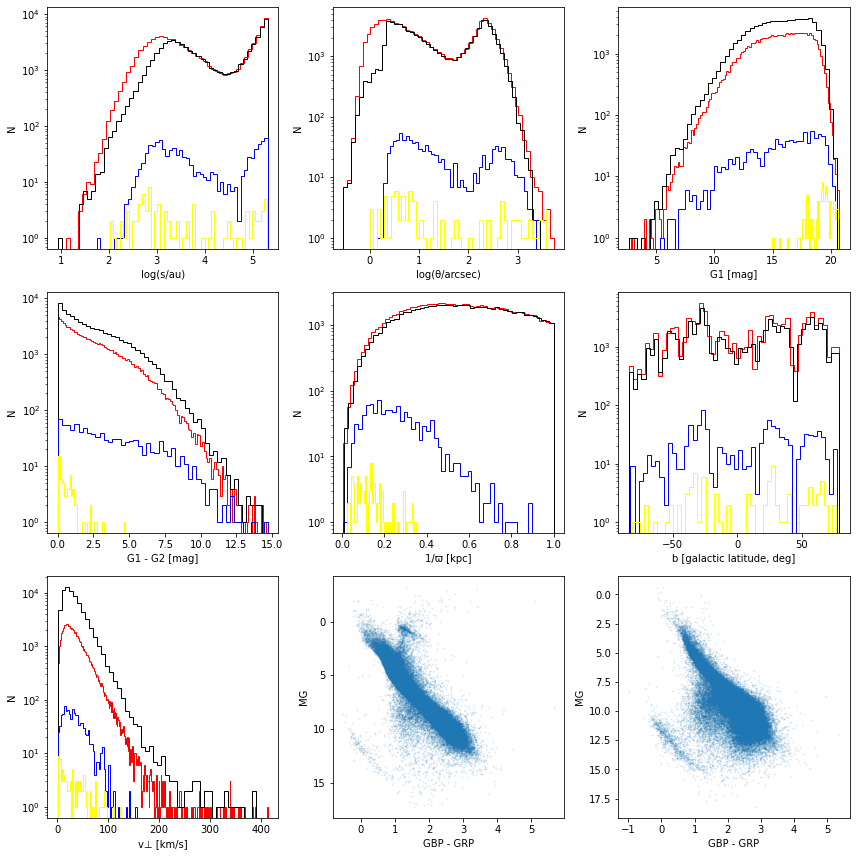

In [5]:
# Create figure with 3x3 subplots
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
plt.subplots_adjust(wspace=0.3, hspace=0.3)

axs[0,0].hist(np.log10(sep_AU), bins='fd', histtype='step', label='All', color='red')
axs[0,0].set_xlabel('log(s/au)')
axs[0,0].set_ylabel('N')
axs[0,0].set_yscale('log')

axs[0,1].hist(np.log10(theta), bins='fd', histtype='step', label='All', color='red')
axs[0,1].set_xlabel('log(θ/arcsec)')
axs[0,1].set_ylabel('N')
axs[0,1].set_yscale('log')

axs[0,2].hist(G1, bins='fd', histtype='step', label='All', color='red')
axs[0,2].set_xlabel('G1 [mag]')
axs[0,2].set_ylabel('N')
axs[0,2].set_yscale('log')

axs[1,0].hist(abs(G1 - G2), bins='fd', histtype='step', label='All', color='red')
axs[1,0].set_xlabel('G1 - G2 [mag]')
axs[1,0].set_ylabel('N')
axs[1,0].set_yscale('log')

axs[1,1].hist(1/parallax, bins='fd', histtype='step', label='All', color='red')
axs[1,1].set_xlabel('1/ϖ [kpc]')
axs[1,1].set_ylabel('N')
axs[1,1].set_yscale('log')

axs[1,2].hist(b, bins='fd', histtype='step', label='All', color='red')
axs[1,2].set_xlabel('b [galactic latitude, deg]')
axs[1,2].set_ylabel('N')
axs[1,2].set_yscale('log')

axs[2,0].hist(v_perp, bins='fd', histtype='step', label='All', color='red')
axs[2,0].set_xlabel('v⊥ [km/s]')
axs[2,0].set_ylabel('N')
axs[2,0].set_yscale('log')

Mg1 = G1 + 5 * np.log10(parallax/100)
axs[2,1].scatter(bp_rp1, Mg1, s=1, alpha=0.1)
axs[2,1].set_xlabel('GBP - GRP')
axs[2,1].set_ylabel('MG')
axs[2,1].invert_yaxis()

Mg2 = G2 + 5 * np.log10(parallax/100)
axs[2,2].scatter(bp_rp2, Mg2, s=1, alpha=0.1)
axs[2,2].set_xlabel('GBP - GRP')
axs[2,2].set_ylabel('MG')
axs[2,2].invert_yaxis()

# Add different binary types in different colors for first 7 plots
binary_types = ['MSMS', 'WDMS', 'WDWD']
colors = ['black', 'blue', 'yellow']

for btype, color in zip(binary_types, colors):
    mask = binary_cat['binary_type'] == btype
    
    for i in range(3):
        for j in range(3):
#             axs[i,j].legend()
            if i == 0 and j == 0:
                axs[i,j].hist(np.log10(sep_AU[mask]), bins=50, histtype='step', color=color, label=btype)
            elif i == 0 and j == 1:
                axs[i,j].hist(np.log10(theta[mask]), bins=50, histtype='step', color=color, label=btype)
            elif i == 0 and j == 2:
                axs[i,j].hist(G1[mask], bins=50, histtype='step', color=color, label=btype)
            elif i == 1 and j == 0:
                axs[i,j].hist(abs(G1[mask] - G2[mask]), bins=50, histtype='step', color=color, label=btype)
            elif i == 1 and j == 1:
                axs[i,j].hist(1/parallax[mask], bins=50, histtype='step', color=color, label=btype)
            elif i == 1 and j == 2:
                axs[i,j].hist(b[mask], bins=50, histtype='step', color=color, label=btype)
            elif i == 2 and j == 0:
                axs[i,j].hist(v_perp[mask], bins=50, histtype='step', color=color, label=btype)

plt.tight_layout()
plt.show()


In [10]:
print(' The median parallax of the full sample is',np.median(parallax),'mas')

 The median parallax of the full sample is 1.8129797923865825 mas


In [8]:
print("The median magnitude of the primaries is 𝐺 =", np.median(G1),
"\n and that of secondaries is 𝐺 =", np.median(G2))

The median magnitude of the primaries is 𝐺 = 15.7246675 
 and that of secondaries is 𝐺 = 18.314186999999997
